# Ping-Pong Delay

A ping-pong delay routes successive echoes to alternating stereo channels. The first echo appears in the **right** channel at `delay_time` seconds; the second in the **left** channel at `2 × delay_time` (attenuated by `feedback`); and so on.

| Parameter | Effect |
| --- | --- |
| `delay_time` | Echo period in seconds (30–200 ms is typical) |
| `feedback` | Gain per bounce; 0 = single echo, 0.9 = many decaying bounces |
| `mix` | Dry/wet blend; 0 = dry only, 1 = wet only |

Internally, `ping_pong_delay` repeatedly applies `fractional_delay_line` — so sub-sample delay accuracy is preserved for any `delay_time`.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.delay import ping_pong_delay

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Echo Pattern on a Click

A single impulse at `t = 0` shows the alternating bounce pattern most clearly.
Each row shows L and R for a different `feedback` value.

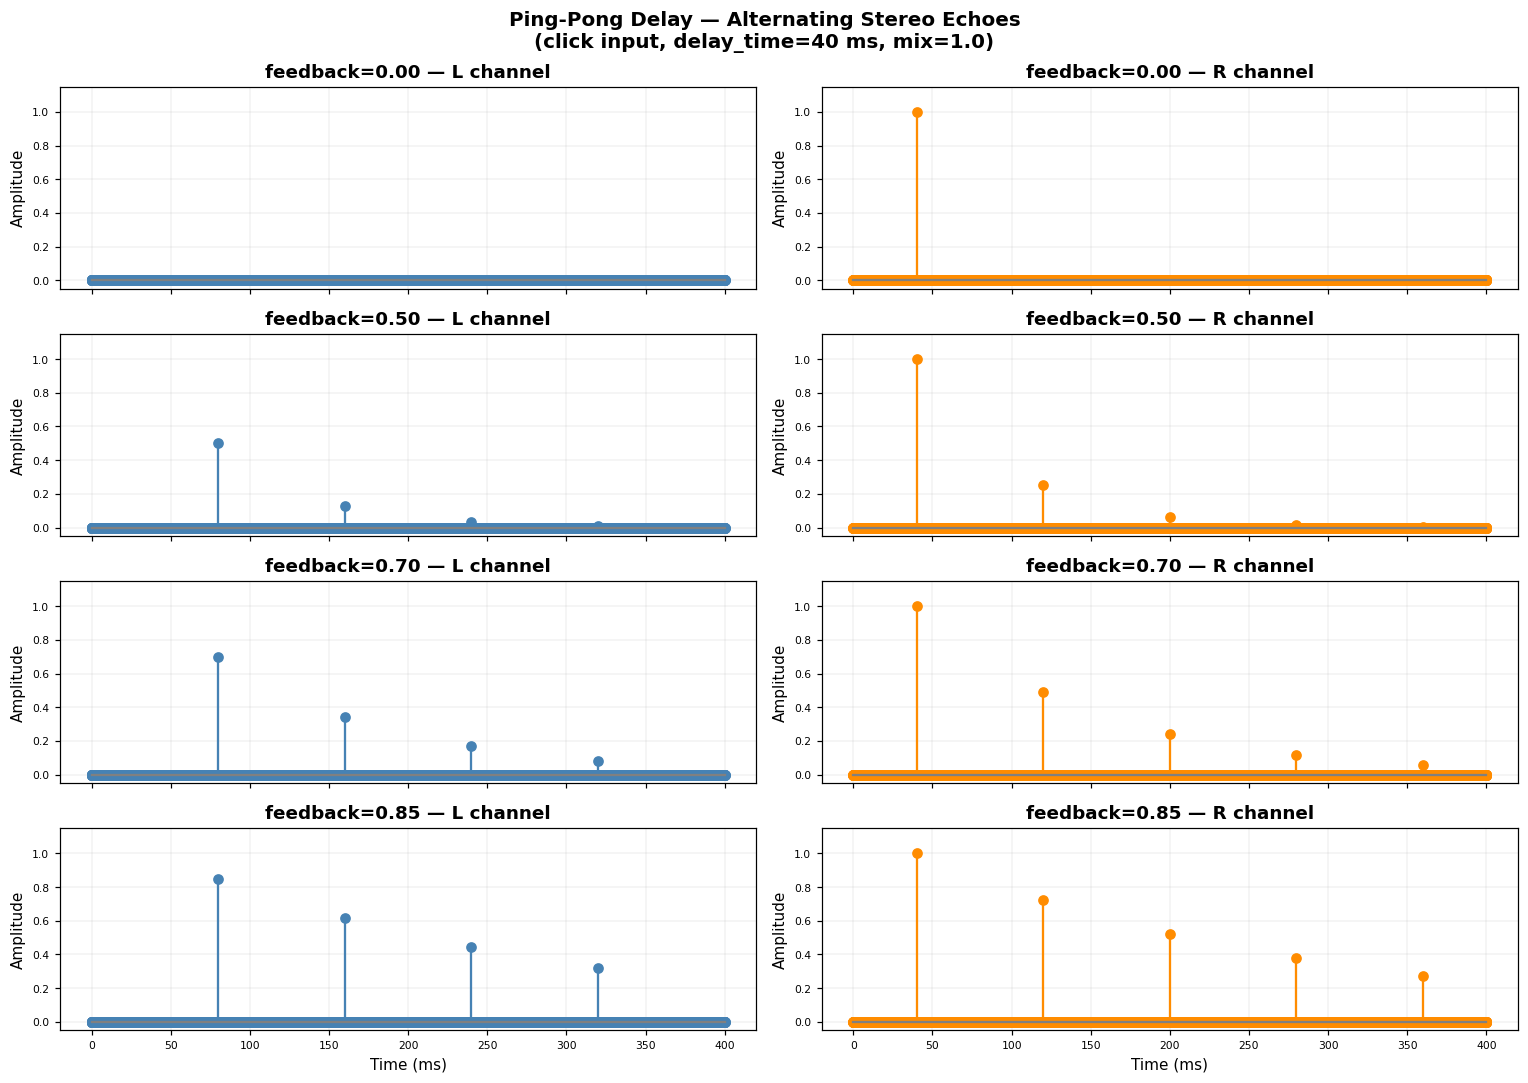

In [2]:
DURATION = 0.4
N = int(DURATION * FS)
click = np.zeros(N)
click[0] = 1.0
t_ms = np.arange(N) / FS * 1000

FEEDBACKS = [0.0, 0.5, 0.7, 0.85]

fig, axes = plt.subplots(len(FEEDBACKS), 2, figsize=(14, 10), sharex=True)

for row, fb in enumerate(FEEDBACKS):
    _, L, R = ping_pong_delay(click, FS, delay_time=0.04, feedback=fb, mix=1.0)

    for ax, signal, color, ch in [
        (axes[row, 0], L, 'steelblue', 'L'),
        (axes[row, 1], R, 'darkorange', 'R'),
    ]:
        ax.stem(t_ms, signal, linefmt=color, markerfmt='o', basefmt='gray')
        ax.set_ylabel('Amplitude')
        ax.set_ylim(-0.05, 1.15)
        ax.set_title(f'feedback={fb:.2f} — {ch} channel', fontweight='bold')
        ax.grid(True, linewidth=0.3, alpha=0.5)
        ax.tick_params(labelsize=7)

for ax in axes[-1]:
    ax.set_xlabel('Time (ms)')

fig.suptitle(
    'Ping-Pong Delay — Alternating Stereo Echoes\n'
    '(click input, delay_time=40 ms, mix=1.0)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Dry / Wet Blend

`mix=0` returns the dry signal in both channels unchanged. `mix=1` gives only the echo trail.

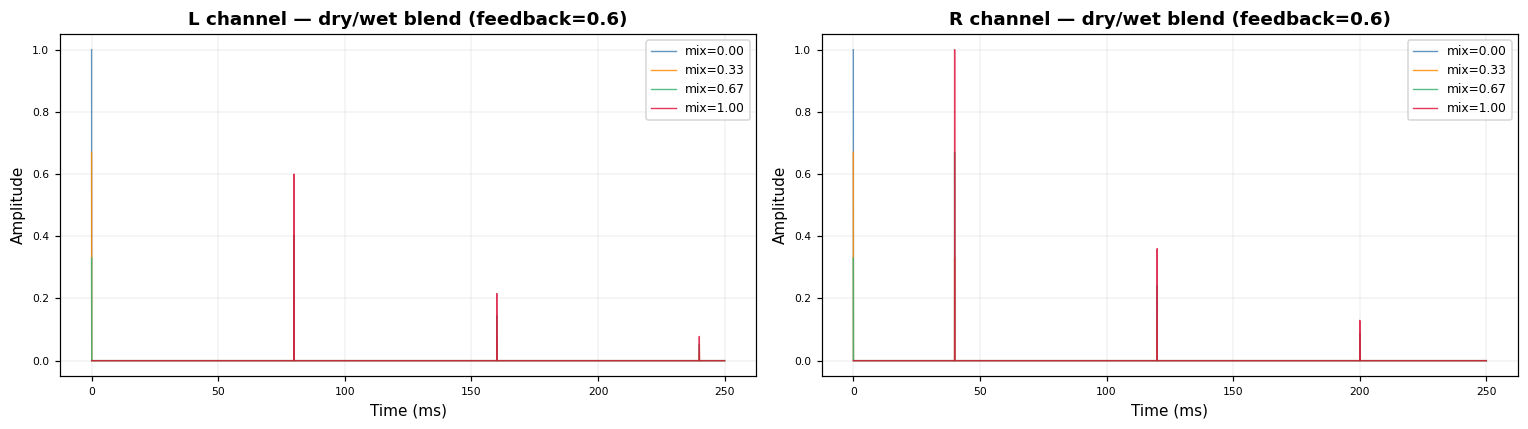

In [3]:
DURATION_SHORT = 0.25
N2 = int(DURATION_SHORT * FS)
click2 = np.zeros(N2)
click2[0] = 1.0
t_ms2 = np.arange(N2) / FS * 1000

MIXES = [0.0, 0.33, 0.67, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']

for mix, color in zip(MIXES, colors):
    _, L, R = ping_pong_delay(click2, FS, delay_time=0.04, feedback=0.6, mix=mix)
    axes[0].plot(t_ms2, L, color=color, linewidth=0.9, label=f'mix={mix:.2f}', alpha=0.85)
    axes[1].plot(t_ms2, R, color=color, linewidth=0.9, label=f'mix={mix:.2f}', alpha=0.85)

for ax, ch in zip(axes, ['L', 'R']):
    ax.set_title(f'{ch} channel — dry/wet blend (feedback=0.6)', fontweight='bold')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=8)
    ax.grid(True, linewidth=0.3, alpha=0.5)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## Verify Echo Positions

With an integer `delay_time × fs`, the echo amplitudes are exact. Let's confirm the alternating pattern numerically.

In [4]:
delay_samples = 500  # integer → exact placement
delay_time = delay_samples / FS
feedback = 0.6

impulse = np.zeros(4096)
impulse[0] = 1.0
_, L, R = ping_pong_delay(impulse, FS, delay_time, feedback=feedback, mix=1.0)

print(f'delay_samples = {delay_samples}, feedback = {feedback}')
print()
print(f'  R[{delay_samples}]      = {R[delay_samples]:.6f}   (expected 1.0)')
print(f'  L[{2*delay_samples}]     = {L[2*delay_samples]:.6f}   (expected {feedback:.6f})')
print(f'  R[{3*delay_samples}]     = {R[3*delay_samples]:.6f}   (expected {feedback**2:.6f})')
print(f'  L[{4*delay_samples}]     = {L[4*delay_samples]:.6f}   (expected {feedback**3:.6f})')
print(f'  R[{5*delay_samples}]     = {R[5*delay_samples]:.6f}   (expected {feedback**4:.6f})')

delay_samples = 500, feedback = 0.6

  R[500]      = 1.000000   (expected 1.0)
  L[1000]     = 0.600000   (expected 0.600000)
  R[1500]     = 0.360000   (expected 0.360000)
  L[2000]     = 0.216000   (expected 0.216000)
  R[2500]     = 0.129600   (expected 0.129600)


## Audio Examples

A single click bounces left and right with feedback, creating the classic ping-pong effect. The stereo alternation is clearly audible on headphones.


In [7]:
from IPython.display import Audio, display

DUR_A = 3.0
N_A   = int(DUR_A * FS)

# 40 ms decaying sine burst — gives each bounce a short audible "ping"
n_burst = int(0.04 * FS)
t_burst = np.arange(n_burst) / FS
burst   = np.sin(2 * np.pi * 300 * t_burst) * np.exp(-t_burst * 60)
click_a = np.zeros(N_A)
click_a[:n_burst] = burst

_, L_pp, R_pp = ping_pong_delay(click_a, FS, delay_time=0.25, feedback=0.6, mix=1.0)

stereo_pp = np.array([L_pp, R_pp])
peak_pp   = np.max(np.abs(stereo_pp))

print("Ping-pong delay (250 ms, feedback=0.6) — alternating L/R echoes with feedback")
display(Audio(stereo_pp / peak_pp * 0.8, rate=FS))

Ping-pong delay (250 ms, feedback=0.6) — alternating L/R echoes with feedback
